1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR

# Optional: XGBoost
try:
    from xgboost import XGBRegressor
    xgb_available = True
except:
    xgb_available = False

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

2. Load Feature-Engineered Dataset

In [2]:
file_path = "StudentPerformanceFactors_psychology_engineered.csv"
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

df.head()

Dataset Shape: (6607, 33)

Columns:
 ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score', 'Motivation_Level_Encoded', 'Peer_Influence_Encoded', 'Access_to_Resources_Encoded', 'Motivation_Normalized', 'Peer_Normalized', 'Resources_Normalized', 'Psychosocial_Resource_Score', 'Motivation_x_Peer', 'Motivation_x_Resources', 'Peer_x_Resources', 'Triadic_Support_Index', 'Psychosocial_Resource_Quartile', 'Focused_Risk_Flag']


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Motivation_Normalized,Peer_Normalized,Resources_Normalized,Psychosocial_Resource_Score,Motivation_x_Peer,Motivation_x_Resources,Peer_x_Resources,Triadic_Support_Index,Psychosocial_Resource_Quartile,Focused_Risk_Flag
0,23,84,Low,High,No,7,73,Low,Yes,0,...,0.0,1.0,1.0,0.750,0.00,0.00,1.00,0.000,Q4_High,Not_At_Risk
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,0.0,0.0,0.5,0.225,0.00,0.00,0.00,0.000,Q1_Low,Not_At_Risk
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,0.5,0.5,0.5,0.500,0.25,0.25,0.25,0.125,Q2,Not_At_Risk
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,0.5,0.0,0.5,0.350,0.00,0.25,0.00,0.000,Q1_Low,Not_At_Risk
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,0.5,0.5,0.5,0.500,0.25,0.25,0.25,0.125,Q2,Not_At_Risk


3. Define Feature Sets

In [3]:
academic_features = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Tutoring_Sessions"
]

raw_psych_features = [
    "Motivation_Level_Encoded",
    "Peer_Influence_Encoded",
    "Access_to_Resources_Encoded"
]

engineered_psych_features = [
    "Psychosocial_Resource_Score",
    "Motivation_x_Peer",
    "Motivation_x_Resources",
    "Peer_x_Resources",
    "Triadic_Support_Index"
]

target_col = "Exam_Score"

X1 = df[academic_features]
X2 = df[academic_features + raw_psych_features]
X3 = df[academic_features + raw_psych_features + engineered_psych_features]
y = df[target_col]

4. Train-Test Split

In [4]:
indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    indices, test_size=0.20, random_state=42
)

X1_train, X1_test = X1.iloc[train_idx], X1.iloc[test_idx]
X2_train, X2_test = X2.iloc[train_idx], X2.iloc[test_idx]
X3_train, X3_test = X3.iloc[train_idx], X3.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))

Train size: 5285
Test size: 1322


5. Define Stronger Model Candidates

In [5]:
def get_models():
    model_dict = {
        "Linear Regression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.001, max_iter=10000),
        "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
        "Random Forest": RandomForestRegressor(
            n_estimators=500, max_depth=None, min_samples_leaf=2, random_state=42
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=500, learning_rate=0.03, max_depth=3, random_state=42
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.05, max_depth=6, random_state=42
        ),
        "SVR": SVR(kernel="rbf", C=15, epsilon=0.05)
    }
    
    if xgb_available:
        model_dict["XGBoost"] = XGBRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.0,
            reg_lambda=1.0,
            random_state=42
        )
    
    return model_dict

models = get_models()
print("Models:", list(models.keys()))

Models: ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'Random Forest', 'Gradient Boosting', 'HistGradientBoosting', 'SVR', 'XGBoost']


6. Cross-Validation + Holdout Evaluation Function

In [6]:
def evaluate_model_set_cv_holdout(X_train, X_test, y_train, y_test, feature_names, set_name):
    results = []
    trained = {}
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), feature_names)
        ]
    )
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    
    for model_name, model in models.items():
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ])
        
        # Cross-validation on training set
        cv_scores = cross_val_score(
            pipeline, X_train, y_train, cv=cv, scoring="r2"
        )
        
        # Fit on full training set
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        test_r2 = r2_score(y_test, y_pred)
        
        results.append({
            "Model_Set": set_name,
            "Model": model_name,
            "CV_R2_Mean": round(cv_scores.mean(), 4),
            "CV_R2_STD": round(cv_scores.std(), 4),
            "Test_MAE": round(mae, 4),
            "Test_RMSE": round(rmse, 4),
            "Test_R2": round(test_r2, 4)
        })
        
        trained[model_name] = pipeline
    
    return pd.DataFrame(results), trained

7. Evaluate All Three Feature Sets

In [7]:
results1, trained1 = evaluate_model_set_cv_holdout(
    X1_train, X1_test, y_train, y_test, academic_features, "Academic_Only"
)

results2, trained2 = evaluate_model_set_cv_holdout(
    X2_train, X2_test, y_train, y_test, academic_features + raw_psych_features, "Academic_Plus_Raw_Psych"
)

results3, trained3 = evaluate_model_set_cv_holdout(
    X3_train, X3_test, y_train, y_test, academic_features + raw_psych_features + engineered_psych_features,
    "Academic_Plus_Engineered_Psych"
)

all_results = pd.concat([results1, results2, results3], axis=0).reset_index(drop=True)

# Sort by Test_R2 primarily, then CV_R2_Mean
all_results = all_results.sort_values(
    by=["Test_R2", "CV_R2_Mean"], ascending=False
).reset_index(drop=True)

display(all_results)

,Model_Set,Model,CV_R2_Mean,CV_R2_STD,Test_MAE,Test_RMSE,Test_R2
0,Academic_Plus_Engineered_Psych,Linear Regression,0.6365,0.0345,1.0289,2.0818,0.6934
1,Academic_Plus_Engineered_Psych,Ridge,0.6365,0.0345,1.0289,2.0818,0.6934
2,Academic_Plus_Engineered_Psych,Lasso,0.6365,0.0344,1.0291,2.0818,0.6934
3,Academic_Plus_Engineered_Psych,ElasticNet,0.6365,0.0344,1.0290,2.0818,0.6934
4,Academic_Plus_Raw_Psych,Linear Regression,0.6372,0.0339,1.0289,2.0821,0.6933
5,Academic_Plus_Raw_Psych,Ridge,0.6372,0.0339,1.0289,2.0820,0.6933
6,Academic_Plus_Raw_Psych,Lasso,0.6372,0.0339,1.0289,2.0820,0.6933
7,Academic_Plus_Raw_Psych,ElasticNet,0.6372,0.0339,1.0289,2.0820,0.6933
8,Academic_Plus_Raw_Psych,Gradient Boosting,0.6152,0.0345,1.1148,2.1289,0.6794
9,Academic_Plus_Engineered_Psych,Gradient Boosting,0.6069,0.0409,1.1185,2.1414,0.6756


8. Best Model per Feature Set

In [14]:
best_per_set = (
    all_results.sort_values(["Model_Set", "Test_R2"], ascending=[True, False])
    .groupby("Model_Set")
    .head(1)
    .reset_index(drop=True)
)

display(best_per_set)

,Model_Set,Model,CV_R2_Mean,CV_R2_STD,Test_MAE,Test_RMSE,Test_R2
0,Academic_Only,Linear Regression,0.5867,0.0272,1.2732,2.2515,0.6414
1,Academic_Plus_Engineered_Psych,Linear Regression,0.6365,0.0345,1.0289,2.0818,0.6934
2,Academic_Plus_Raw_Psych,Linear Regression,0.6372,0.0339,1.0289,2.0821,0.6933


9. Select Final Best Overall Model

In [15]:
best_row = all_results.iloc[0]

best_model_set = best_row["Model_Set"]
best_model_name = best_row["Model"]

print("Best Overall Model Set:", best_model_set)
print("Best Overall Model:", best_model_name)

if best_model_set == "Academic_Only":
    best_model = trained1[best_model_name]
    best_features = academic_features
    X_best = X1
elif best_model_set == "Academic_Plus_Raw_Psych":
    best_model = trained2[best_model_name]
    best_features = academic_features + raw_psych_features
    X_best = X2
else:
    best_model = trained3[best_model_name]
    best_features = academic_features + raw_psych_features + engineered_psych_features
    X_best = X3

print("Best Features:", best_features)

Best Overall Model Set: Academic_Plus_Engineered_Psych
Best Overall Model: Linear Regression
Best Features: ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Motivation_Level_Encoded', 'Peer_Influence_Encoded', 'Access_to_Resources_Encoded', 'Psychosocial_Resource_Score', 'Motivation_x_Peer', 'Motivation_x_Resources', 'Peer_x_Resources', 'Triadic_Support_Index']


10. Optional Feature Importance (Tree Models Only)

In [16]:
tree_models = ["Random Forest", "Gradient Boosting", "XGBoost"]

if best_model_name in tree_models:
    model_step = best_model.named_steps["model"]
    
    if hasattr(model_step, "feature_importances_"):
        fi_df = pd.DataFrame({
            "Feature": best_features,
            "Importance": model_step.feature_importances_
        }).sort_values(by="Importance", ascending=False)
        
        display(fi_df)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(data=fi_df, x="Importance", y="Feature")
        plt.title(f"Feature Importance - {best_model_name} ({best_model_set})")
        plt.show()
else:
    print("Best model is not a feature-importance tree model; skipping.")

Best model is not a feature-importance tree model; skipping.


 11. Helper Function to Recompute Engineered Features

In [17]:
def recompute_psych_features(temp_df):
    df_temp = temp_df.copy()
    
    df_temp["Motivation_Normalized"] = (df_temp["Motivation_Level_Encoded"] - 1) / 2
    df_temp["Peer_Normalized"] = (df_temp["Peer_Influence_Encoded"] - 1) / 2
    df_temp["Resources_Normalized"] = (df_temp["Access_to_Resources_Encoded"] - 1) / 2
    
    df_temp["Psychosocial_Resource_Score"] = (
        df_temp["Motivation_Normalized"] * 0.25 +
        df_temp["Peer_Normalized"] * 0.30 +
        df_temp["Resources_Normalized"] * 0.45
    )
    
    df_temp["Motivation_x_Peer"] = df_temp["Motivation_Normalized"] * df_temp["Peer_Normalized"]
    df_temp["Motivation_x_Resources"] = df_temp["Motivation_Normalized"] * df_temp["Resources_Normalized"]
    df_temp["Peer_x_Resources"] = df_temp["Peer_Normalized"] * df_temp["Resources_Normalized"]
    df_temp["Triadic_Support_Index"] = (
        df_temp["Motivation_Normalized"] *
        df_temp["Peer_Normalized"] *
        df_temp["Resources_Normalized"]
    )
    
    return df_temp

12. Build Full Baseline Profiles

In [18]:
# Full feature space for simulation
full_mean_profile = X3.mean().to_frame().T
full_mean_profile.index = ["Average_Student"]

# At-risk student profile:
# Lower academic support + worst psychosocial/cognitive levels
at_risk_profile = pd.DataFrame([{
    "Hours_Studied": df["Hours_Studied"].quantile(0.25),
    "Attendance": df["Attendance"].quantile(0.25),
    "Previous_Scores": df["Previous_Scores"].quantile(0.25),
    "Tutoring_Sessions": df["Tutoring_Sessions"].quantile(0.25),
    "Motivation_Level_Encoded": 1,
    "Peer_Influence_Encoded": 1,
    "Access_to_Resources_Encoded": 1,
    "Psychosocial_Resource_Score": 0,
    "Motivation_x_Peer": 0,
    "Motivation_x_Resources": 0,
    "Peer_x_Resources": 0,
    "Triadic_Support_Index": 0
}], index=["At_Risk_Student"])

at_risk_profile = recompute_psych_features(at_risk_profile)

display(full_mean_profile)
display(at_risk_profile)

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Motivation_Level_Encoded,Peer_Influence_Encoded,Access_to_Resources_Encoded,Psychosocial_Resource_Score,Motivation_x_Peer,Motivation_x_Resources,Peer_x_Resources,Triadic_Support_Index
Average_Student,19.975329,79.977448,75.070531,1.493719,1.906463,2.190858,2.100197,0.539481,0.269827,0.250076,0.32738,0.149292


,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Motivation_Level_Encoded,Peer_Influence_Encoded,Access_to_Resources_Encoded,Psychosocial_Resource_Score,Motivation_x_Peer,Motivation_x_Resources,Peer_x_Resources,Triadic_Support_Index,Motivation_Normalized,Peer_Normalized,Resources_Normalized
At_Risk_Student,16.0,70.0,63.0,1.0,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


13. Helper Function to Predict from Full Profile

In [20]:
def predict_from_full_profile(full_profile):
    full_profile = recompute_psych_features(full_profile)
    profile_for_model = full_profile[best_features]
    pred = best_model.predict(profile_for_model)[0]
    return pred

14. Baseline Predictions

In [21]:
avg_baseline_pred = predict_from_full_profile(full_mean_profile)
at_risk_baseline_pred = predict_from_full_profile(at_risk_profile)

print(f"Average Student Baseline Prediction: {avg_baseline_pred:.2f}")
print(f"At-Risk Student Baseline Prediction: {at_risk_baseline_pred:.2f}")

Average Student Baseline Prediction: 67.24
At-Risk Student Baseline Prediction: 60.96


15. Average Student - Realistic Intervention Packages

In [22]:
avg_interventions = []

avg_cases = [
    ("Baseline", 2, 2, 2),
    ("Motivation Support (Low→Medium style)", 3, 2, 2),
    ("Peer Mentoring (Negative→Neutral style)", 2, 3, 2),
    ("Resource Assistance (Low→Medium style)", 2, 2, 3),
    ("Moderate Integrated Support", 3, 3, 3)
]

for label, m, p, r in avg_cases:
    temp = full_mean_profile.copy()
    temp["Motivation_Level_Encoded"] = m
    temp["Peer_Influence_Encoded"] = p
    temp["Access_to_Resources_Encoded"] = r
    
    pred = predict_from_full_profile(temp)
    
    avg_interventions.append({
        "Scenario": label,
        "Predicted_Exam_Score": round(pred, 2),
        "Gain_vs_Average_Baseline": round(pred - avg_baseline_pred, 2)
    })

avg_interventions_df = pd.DataFrame(avg_interventions)
display(avg_interventions_df)

,Scenario,Predicted_Exam_Score,Gain_vs_Average_Baseline
0,Baseline,67.08,-0.16
1,Motivation Support (Low→Medium style),67.59,0.36
2,Peer Mentoring (Negative→Neutral style),67.63,0.40
3,Resource Assistance (Low→Medium style),68.08,0.84
4,Moderate Integrated Support,69.25,2.01


16. At-Risk Student - Realistic Intervention Packages

In [23]:
risk_interventions = []

risk_cases = [
    ("Baseline At-Risk", 1, 1, 1),
    ("Counseling / Motivation Support", 2, 1, 1),
    ("Peer Mentoring", 1, 2, 1),
    ("Resource Assistance", 1, 1, 2),
    ("Moderate Integrated Support", 2, 2, 2),
    ("Intensive Integrated Support", 3, 3, 3)
]

for label, m, p, r in risk_cases:
    temp = at_risk_profile.copy()
    temp["Motivation_Level_Encoded"] = m
    temp["Peer_Influence_Encoded"] = p
    temp["Access_to_Resources_Encoded"] = r
    
    pred = predict_from_full_profile(temp)
    
    risk_interventions.append({
        "Scenario": label,
        "Predicted_Exam_Score": round(pred, 2),
        "Gain_vs_At_Risk_Baseline": round(pred - at_risk_baseline_pred, 2)
    })

risk_interventions_df = pd.DataFrame(risk_interventions)
display(risk_interventions_df)

,Scenario,Predicted_Exam_Score,Gain_vs_At_Risk_Baseline
0,Baseline At-Risk,60.96,0.00
1,Counseling / Motivation Support,61.55,0.59
2,Peer Mentoring,61.60,0.64
3,Resource Assistance,62.07,1.11
4,Moderate Integrated Support,63.11,2.15
5,Intensive Integrated Support,65.28,4.32


17. Classic Full-Range Single-Factor What-Ifs

In [24]:
single_factor_summary = []

# Motivation 1->3 on average profile
temp_low = full_mean_profile.copy()
temp_low["Motivation_Level_Encoded"] = 1
pred_low = predict_from_full_profile(temp_low)

temp_high = full_mean_profile.copy()
temp_high["Motivation_Level_Encoded"] = 3
pred_high = predict_from_full_profile(temp_high)

single_factor_summary.append({
    "Intervention": "Motivation: Low → High",
    "Predicted_Mark_Gain": round(pred_high - pred_low, 2)
})

# Peer 1->3
temp_low = full_mean_profile.copy()
temp_low["Peer_Influence_Encoded"] = 1
pred_low = predict_from_full_profile(temp_low)

temp_high = full_mean_profile.copy()
temp_high["Peer_Influence_Encoded"] = 3
pred_high = predict_from_full_profile(temp_high)

single_factor_summary.append({
    "Intervention": "Peer Influence: Negative → Positive",
    "Predicted_Mark_Gain": round(pred_high - pred_low, 2)
})

# Resources 1->3
temp_low = full_mean_profile.copy()
temp_low["Access_to_Resources_Encoded"] = 1
pred_low = predict_from_full_profile(temp_low)

temp_high = full_mean_profile.copy()
temp_high["Access_to_Resources_Encoded"] = 3
pred_high = predict_from_full_profile(temp_high)

single_factor_summary.append({
    "Intervention": "Access to Resources: Low → High",
    "Predicted_Mark_Gain": round(pred_high - pred_low, 2)
})

# Combined 1,1,1 -> 3,3,3
temp_low = full_mean_profile.copy()
temp_low["Motivation_Level_Encoded"] = 1
temp_low["Peer_Influence_Encoded"] = 1
temp_low["Access_to_Resources_Encoded"] = 1
pred_low = predict_from_full_profile(temp_low)

temp_high = full_mean_profile.copy()
temp_high["Motivation_Level_Encoded"] = 3
temp_high["Peer_Influence_Encoded"] = 3
temp_high["Access_to_Resources_Encoded"] = 3
pred_high = predict_from_full_profile(temp_high)

single_factor_summary.append({
    "Intervention": "All Three Combined: Low/Negative/Low → High/Positive/High",
    "Predicted_Mark_Gain": round(pred_high - pred_low, 2)
})

single_factor_summary_df = pd.DataFrame(single_factor_summary).sort_values(
    by="Predicted_Mark_Gain", ascending=False
).reset_index(drop=True)

display(single_factor_summary_df)

,Intervention,Predicted_Mark_Gain
0,All Three Combined: Low/Negative/Low → High/Po...,4.32
1,Access to Resources: Low → High,1.99
2,Peer Influence: Negative → Positive,1.10
3,Motivation: Low → High,1.04


18. School-Facing Ranked Summary (At-Risk Student Focus)

In [25]:
school_ranked_summary = risk_interventions_df.copy()
school_ranked_summary = school_ranked_summary.sort_values(
    by="Gain_vs_At_Risk_Baseline", ascending=False
).reset_index(drop=True)

display(school_ranked_summary)

,Scenario,Predicted_Exam_Score,Gain_vs_At_Risk_Baseline
0,Intensive Integrated Support,65.28,4.32
1,Moderate Integrated Support,63.11,2.15
2,Resource Assistance,62.07,1.11
3,Peer Mentoring,61.60,0.64
4,Counseling / Motivation Support,61.55,0.59
5,Baseline At-Risk,60.96,0.00


19. Generate Human-Readable Insights

In [26]:
print("=== SCHOOL-FACING INSIGHTS (AT-RISK STUDENT) ===\n")
for _, row in school_ranked_summary.iterrows():
    if row["Scenario"] != "Baseline At-Risk":
        print(f"- {row['Scenario']} predicts an estimated +{row['Gain_vs_At_Risk_Baseline']} mark improvement for an at-risk student.")

print("\n=== CLASSIC PAPER-STYLE SINGLE-FACTOR INSIGHTS ===\n")
for _, row in single_factor_summary_df.iterrows():
    print(f"- If {row['Intervention']}, the model predicts an average increase of {row['Predicted_Mark_Gain']} marks.")

=== SCHOOL-FACING INSIGHTS (AT-RISK STUDENT) ===

- Intensive Integrated Support predicts an estimated +4.32 mark improvement for an at-risk student.
- Moderate Integrated Support predicts an estimated +2.15 mark improvement for an at-risk student.
- Resource Assistance predicts an estimated +1.11 mark improvement for an at-risk student.
- Peer Mentoring predicts an estimated +0.64 mark improvement for an at-risk student.
- Counseling / Motivation Support predicts an estimated +0.59 mark improvement for an at-risk student.

=== CLASSIC PAPER-STYLE SINGLE-FACTOR INSIGHTS ===

- If All Three Combined: Low/Negative/Low → High/Positive/High, the model predicts an average increase of 4.32 marks.
- If Access to Resources: Low → High, the model predicts an average increase of 1.99 marks.
- If Peer Influence: Negative → Positive, the model predicts an average increase of 1.1 marks.
- If Motivation: Low → High, the model predicts an average increase of 1.04 marks.


20. Visualizations

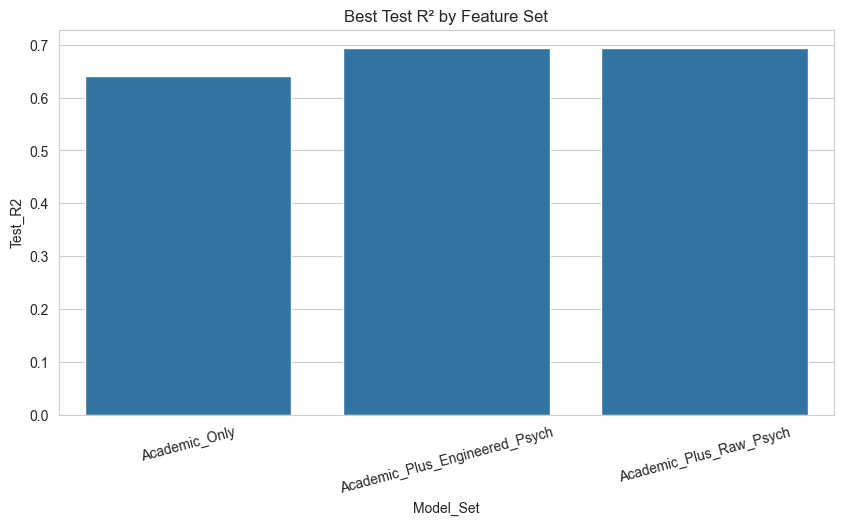

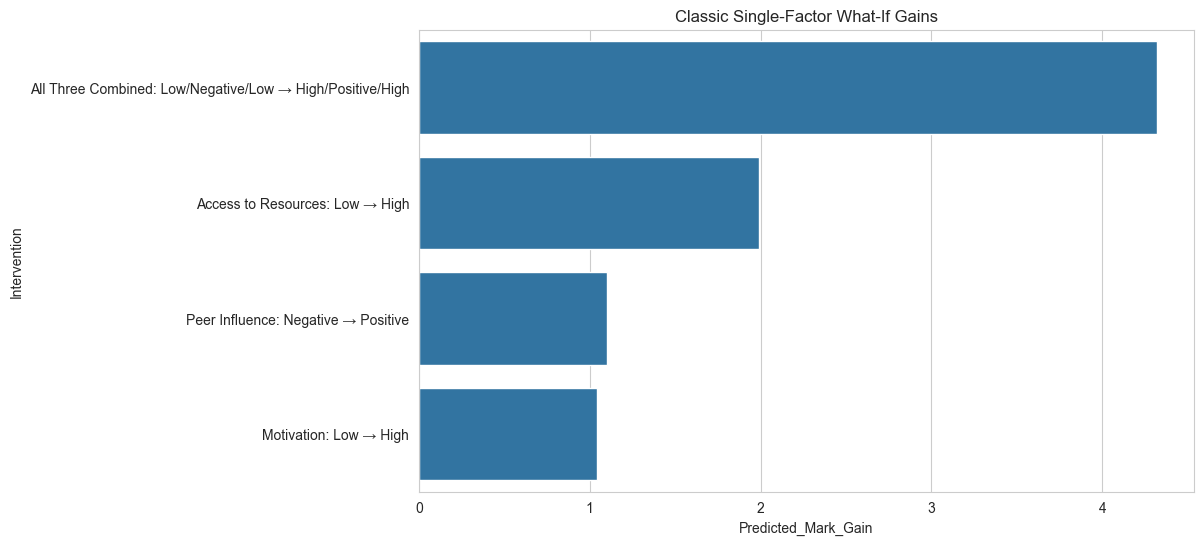

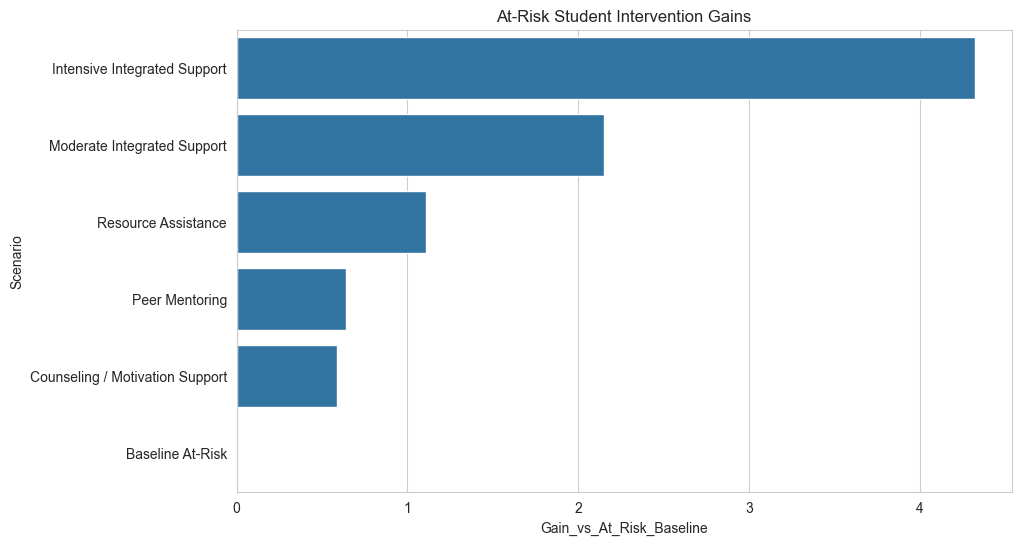

In [27]:
plt.figure(figsize=(10, 5))
sns.barplot(data=best_per_set, x="Model_Set", y="Test_R2")
plt.title("Best Test R² by Feature Set")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=single_factor_summary_df, x="Predicted_Mark_Gain", y="Intervention")
plt.title("Classic Single-Factor What-If Gains")
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=school_ranked_summary, x="Gain_vs_At_Risk_Baseline", y="Scenario")
plt.title("At-Risk Student Intervention Gains")
plt.show()

21. Save Outputs

In [28]:
all_results.to_csv("enhanced_comparative_model_results.csv", index=False)
best_per_set.to_csv("enhanced_best_model_per_set.csv", index=False)
avg_interventions_df.to_csv("average_student_interventions.csv", index=False)
risk_interventions_df.to_csv("at_risk_student_interventions.csv", index=False)
single_factor_summary_df.to_csv("classic_single_factor_summary.csv", index=False)
school_ranked_summary.to_csv("school_ranked_summary_at_risk.csv", index=False)

print("Enhanced Notebook 3 outputs saved successfully.")

Enhanced Notebook 3 outputs saved successfully.


22. Final Summary

In [29]:
print("=== ENHANCED NOTEBOOK 3 COMPLETE ===")
print(f"Best Model Set: {best_model_set}")
print(f"Best Model: {best_model_name}")
print(f"Average Student Baseline Prediction: {avg_baseline_pred:.2f}")
print(f"At-Risk Student Baseline Prediction: {at_risk_baseline_pred:.2f}")

print("\nTop Results:")
display(all_results.head(10))

print("\nBest per Feature Set:")
display(best_per_set)

print("\nClassic Single-Factor Summary:")
display(single_factor_summary_df)

print("\nAt-Risk Student Ranked Intervention Summary:")
display(school_ranked_summary)

=== ENHANCED NOTEBOOK 3 COMPLETE ===
Best Model Set: Academic_Plus_Engineered_Psych
Best Model: Linear Regression
Average Student Baseline Prediction: 67.24
At-Risk Student Baseline Prediction: 60.96

Top Results:


,Model_Set,Model,CV_R2_Mean,CV_R2_STD,Test_MAE,Test_RMSE,Test_R2
0,Academic_Plus_Engineered_Psych,Linear Regression,0.6365,0.0345,1.0289,2.0818,0.6934
1,Academic_Plus_Engineered_Psych,Ridge,0.6365,0.0345,1.0289,2.0818,0.6934
2,Academic_Plus_Engineered_Psych,Lasso,0.6365,0.0344,1.0291,2.0818,0.6934
3,Academic_Plus_Engineered_Psych,ElasticNet,0.6365,0.0344,1.0290,2.0818,0.6934
4,Academic_Plus_Raw_Psych,Linear Regression,0.6372,0.0339,1.0289,2.0821,0.6933
5,Academic_Plus_Raw_Psych,Ridge,0.6372,0.0339,1.0289,2.0820,0.6933
6,Academic_Plus_Raw_Psych,Lasso,0.6372,0.0339,1.0289,2.0820,0.6933
7,Academic_Plus_Raw_Psych,ElasticNet,0.6372,0.0339,1.0289,2.0820,0.6933
8,Academic_Plus_Raw_Psych,Gradient Boosting,0.6152,0.0345,1.1148,2.1289,0.6794
9,Academic_Plus_Engineered_Psych,Gradient Boosting,0.6069,0.0409,1.1185,2.1414,0.6756



Best per Feature Set:


,Model_Set,Model,CV_R2_Mean,CV_R2_STD,Test_MAE,Test_RMSE,Test_R2
0,Academic_Only,Linear Regression,0.5867,0.0272,1.2732,2.2515,0.6414
1,Academic_Plus_Engineered_Psych,Linear Regression,0.6365,0.0345,1.0289,2.0818,0.6934
2,Academic_Plus_Raw_Psych,Linear Regression,0.6372,0.0339,1.0289,2.0821,0.6933



Classic Single-Factor Summary:


,Intervention,Predicted_Mark_Gain
0,All Three Combined: Low/Negative/Low → High/Po...,4.32
1,Access to Resources: Low → High,1.99
2,Peer Influence: Negative → Positive,1.10
3,Motivation: Low → High,1.04



At-Risk Student Ranked Intervention Summary:


,Scenario,Predicted_Exam_Score,Gain_vs_At_Risk_Baseline
0,Intensive Integrated Support,65.28,4.32
1,Moderate Integrated Support,63.11,2.15
2,Resource Assistance,62.07,1.11
3,Peer Mentoring,61.60,0.64
4,Counseling / Motivation Support,61.55,0.59
5,Baseline At-Risk,60.96,0.00
